<a href="https://colab.research.google.com/github/ajengfirdyaramadany-bot/DATA-MINING/blob/main/tugas_individu_pdab_metode_knn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **ANALISIS DATA ECCOMERCE CUSTOMER KNN - AJENG FIRDYA RAMADANY 2404220007**

# DATA CLEANING

Import Library

In [ ]:
import pandas as pd

Load Dataset

In [ ]:
df = pd.read_csv('/content/data_ecommerce_customer_churn.csv')

print("Shape dataset:", df.shape)
df.head()

Shape dataset: (3941, 11)


,Tenure,WarehouseToHome,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn
0,15.0,29.0,4,Laptop & Accessory,3,Single,2,0,7.0,143.32,0
1,7.0,25.0,4,Mobile,1,Married,2,0,7.0,129.29,0
2,27.0,13.0,3,Laptop & Accessory,1,Married,5,0,7.0,168.54,0
3,20.0,25.0,4,Fashion,3,Divorced,7,0,NaN,230.27,0
4,30.0,15.0,4,Others,4,Single,8,0,8.0,322.17,0


Standarisasi Nama Kolom

In [ ]:
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
)

print("Columns:")
print(df.columns)

Columns:
Index(['tenure', 'warehousetohome', 'numberofdeviceregistered',
       'preferedordercat', 'satisfactionscore', 'maritalstatus',
       'numberofaddress', 'complain', 'daysincelastorder', 'cashbackamount',
       'churn'],
      dtype='object')


Hapus Kolom ID

In [ ]:
if "id" in df.columns:
    df.drop(columns=["id"], inplace=True)

print("Shape setelah drop ID:", df.shape)
df.head()

Shape setelah drop ID: (3941, 11)


,tenure,warehousetohome,numberofdeviceregistered,preferedordercat,satisfactionscore,maritalstatus,numberofaddress,complain,daysincelastorder,cashbackamount,churn
0,15.0,29.0,4,Laptop & Accessory,3,Single,2,0,7.0,143.32,0
1,7.0,25.0,4,Mobile,1,Married,2,0,7.0,129.29,0
2,27.0,13.0,3,Laptop & Accessory,1,Married,5,0,7.0,168.54,0
3,20.0,25.0,4,Fashion,3,Divorced,7,0,NaN,230.27,0
4,30.0,15.0,4,Others,4,Single,8,0,8.0,322.17,0


Cek Missing Value

In [ ]:
missing = df.isnull().sum()
print(missing)

tenure                      194
warehousetohome             169
numberofdeviceregistered      0
preferedordercat              0
satisfactionscore             0
maritalstatus                 0
numberofaddress               0
complain                      0
daysincelastorder           213
cashbackamount                0
churn                         0
dtype: int64


Missing values yang cukup banyak pada beberapa variabel dapat mempengaruhi performa model jika tidak ditangani dengan baik. Oleh karena itu, dilakukan proses imputasi untuk mengisi nilai yang hilang agar distribusi data tetap terjaga dan tidak mengurangi jumlah data secara signifikan.

Cek Data Duplikat

In [ ]:
duplicates = df.duplicated().sum()
print("Jumlah duplikat:", duplicates)

df = df.drop_duplicates()

Jumlah duplikat: 671


Berdasarkan hasil pengecekan, ditemukan sebanyak 671 data duplikat pada dataset. Jumlah ini tergolong cukup banyak dan berpotensi mempengaruhi hasil analisis serta performa model, karena data yang sama dapat menyebabkan bias dalam proses pembelajaran model.

Cek Tipe Data

In [ ]:
print(df.dtypes)

tenure                      float64
warehousetohome             float64
numberofdeviceregistered      int64
preferedordercat             object
satisfactionscore             int64
maritalstatus                object
numberofaddress               int64
complain                      int64
daysincelastorder           float64
cashbackamount              float64
churn                         int64
dtype: object


Distribusi Target

In [ ]:
df["churn"].value_counts()

,count
churn,
0,2736
1,534


Berdasarkan hasil distribusi data, diketahui bahwa jumlah pelanggan yang tidak churn (0) sebanyak 2736 data, sedangkan pelanggan yang churn (1) sebanyak 534 data.

Hal ini menunjukkan bahwa data memiliki ketidakseimbangan (imbalanced data), di mana jumlah pelanggan yang tidak churn jauh lebih banyak dibandingkan pelanggan yang churn.

Shape Dataset

In [ ]:
print("Shape setelah cleaning:", df.shape)

df_clean = df.copy()
df_clean.head()

Shape setelah cleaning: (3270, 11)


,tenure,warehousetohome,numberofdeviceregistered,preferedordercat,satisfactionscore,maritalstatus,numberofaddress,complain,daysincelastorder,cashbackamount,churn
0,15.0,29.0,4,Laptop & Accessory,3,Single,2,0,7.0,143.32,0
1,7.0,25.0,4,Mobile,1,Married,2,0,7.0,129.29,0
2,27.0,13.0,3,Laptop & Accessory,1,Married,5,0,7.0,168.54,0
3,20.0,25.0,4,Fashion,3,Divorced,7,0,NaN,230.27,0
4,30.0,15.0,4,Others,4,Single,8,0,8.0,322.17,0


Berdasarkan hasil data cleaning, diperoleh dataset dengan jumlah 3270 baris (data) dan 11 kolom (variabel). Hal ini menunjukkan bahwa data telah melalui proses pembersihan seperti penghapusan data duplikat dan penanganan missing values sehingga jumlah data menjadi lebih terstruktur dan siap digunakan untuk analisis lebih lanjut.

# DATA TRANSFORMATION

Label Encoding Target

In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df_clean["churn"] = encoder.fit_transform(df_clean["churn"])

df_clean.head()

,tenure,warehousetohome,numberofdeviceregistered,preferedordercat,satisfactionscore,maritalstatus,numberofaddress,complain,daysincelastorder,cashbackamount,churn
0,15.0,29.0,4,Laptop & Accessory,3,Single,2,0,7.0,143.32,0
1,7.0,25.0,4,Mobile,1,Married,2,0,7.0,129.29,0
2,27.0,13.0,3,Laptop & Accessory,1,Married,5,0,7.0,168.54,0
3,20.0,25.0,4,Fashion,3,Divorced,7,0,NaN,230.27,0
4,30.0,15.0,4,Others,4,Single,8,0,8.0,322.17,0


Pada tahap ini dilakukan proses label encoding terhadap variabel target yaitu churn, dengan tujuan mengubah data kategorik menjadi bentuk numerik agar dapat diproses oleh algoritma machine learning.

Berdasarkan hasil yang ditampilkan, variabel churn telah berhasil direpresentasikan dalam bentuk numerik, di mana nilai 0 menunjukkan pelanggan tidak churn dan nilai 1 menunjukkan pelanggan churn.

Pisahkan Feature dan Target

In [ ]:
df_clean = pd.get_dummies(df_clean, drop_first=True)

# Pisahkan feature (X) dan target (y)
X = df_clean.drop(columns=["churn"])
y = df_clean["churn"]

print("Shape Feature:", X.shape)
print("Shape Target:", y.shape)

Shape Feature: (3270, 15)
Shape Target: (3270,)


Berdasarkan hasil pemisahan data, diperoleh bahwa variabel feature (X) memiliki ukuran (3270, 15), yang berarti terdapat 3270 data dengan 15 variabel fitur yang digunakan sebagai input dalam model.

Sedangkan variabel target (y) memiliki ukuran (3270,), yang menunjukkan bahwa terdapat 3270 label data yang akan diprediksi oleh model, yaitu status churn.

Cek Data Setelah Transformasi

In [ ]:
print(X.head())
print("\nTarget sample:")
print(y.head())

   tenure  warehousetohome  numberofdeviceregistered  satisfactionscore  \
0    15.0             29.0                         4                  3   
1     7.0             25.0                         4                  1   
2    27.0             13.0                         3                  1   
3    20.0             25.0                         4                  3   
4    30.0             15.0                         4                  4   

   numberofaddress  complain  daysincelastorder  cashbackamount  \
0                2         0                7.0          143.32   
1                2         0                7.0          129.29   
2                5         0                7.0          168.54   
3                7         0                NaN          230.27   
4                8         0                8.0          322.17   

   preferedordercat_Grocery  preferedordercat_Laptop & Accessory  \
0                     False                                 True   
1         

Berdasarkan hasil transformasi data, terlihat bahwa variabel kategorik seperti preferedordercat dan maritalstatus telah berhasil diubah menjadi beberapa variabel numerik menggunakan metode One Hot Encoding. Hal ini ditunjukkan dengan munculnya kolom baru seperti preferedordercat_Grocery, preferedordercat_Mobile, serta maritalstatus_Married dan maritalstatus_Single yang berisi nilai True/False.

Perubahan ini bertujuan agar data kategorik dapat diproses oleh algoritma machine learning, khususnya KNN, tanpa menimbulkan bias urutan antar kategori.

# DATA SPLITTING

Train Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Shape X_train:", X_train.shape)
print("Shape X_test :", X_test.shape)
print("Shape y_train:", y_train.shape)
print("Shape y_test :", y_test.shape)

Shape X_train: (2616, 15)
Shape X_test : (654, 15)
Shape y_train: (2616,)
Shape y_test : (654,)


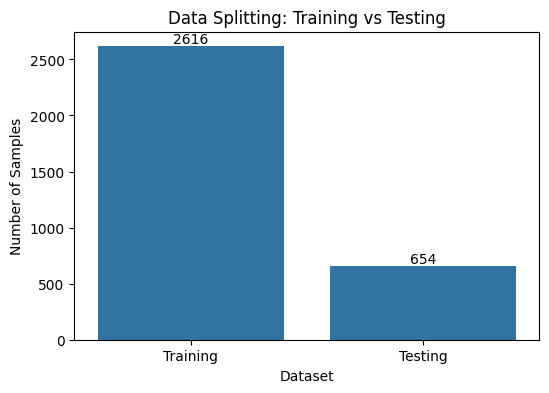

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Hitung jumlah data
split_counts = {
    "Training": X_train.shape[0],
    "Testing": X_test.shape[0]
}

# Visualisasi
plt.figure(figsize=(6,4))
sns.barplot(
    x=list(split_counts.keys()),
    y=list(split_counts.values())
)

plt.title("Data Splitting: Training vs Testing")
plt.ylabel("Number of Samples")
plt.xlabel("Dataset")

# Tambahkan label angka di atas bar
for i, v in enumerate(split_counts.values()):
    plt.text(i, v, str(v), ha='center', va='bottom')

plt.show()

Berdasarkan visualisasi, data telah dibagi menjadi dua bagian yaitu data training sebanyak 2616 data dan data testing sebanyak 654 data.

Pembagian ini menunjukkan proporsi sekitar 80% untuk training dan 20% untuk testing, yang merupakan pembagian yang umum digunakan dalam machine learning.

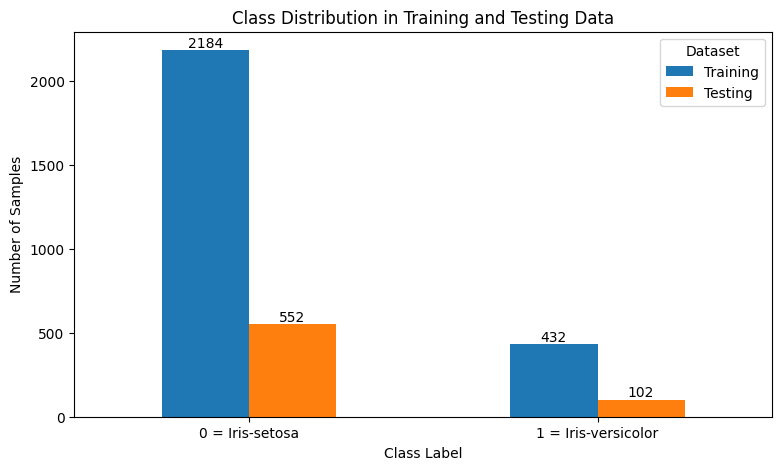

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Buat tabel distribusi kelas
train_counts = pd.Series(y_train).value_counts().sort_index()
test_counts = pd.Series(y_test).value_counts().sort_index()

class_dist = pd.DataFrame({
    "Training": train_counts,
    "Testing": test_counts
})

# Ubah label index jadi lebih jelas
class_labels = {
    0: "0 = Iris-setosa",
    1: "1 = Iris-versicolor",
    2: "2 = Iris-virginica"
}

class_dist.index = [class_labels[i] for i in class_dist.index]

# Plot
ax = class_dist.plot(kind="bar", figsize=(9,5))

plt.title("Class Distribution in Training and Testing Data")
plt.xlabel("Class Label")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.legend(title="Dataset")

# Tambahkan angka di atas bar
for container in ax.containers:
    ax.bar_label(container, fmt='%d')

plt.show()

Berdasarkan distribusi kelas pada data training, diketahui bahwa jumlah data tidak churn (0) sebanyak 2184 data, sedangkan churn (1) sebanyak 432 data.

Hal ini menunjukkan bahwa data training memiliki ketidakseimbangan kelas (imbalanced), di mana kelas tidak churn lebih dominan dibandingkan churn. Kondisi ini dapat mempengaruhi model dalam proses pembelajaran karena model cenderung lebih sering melihat kelas mayoritas.

Cek Distribusi Data Training dan Testing

In [ ]:
print("Distribusi kelas pada training data:")
print(y_train.value_counts())

print("\nDistribusi kelas pada testing data:")
print(y_test.value_counts())

Distribusi kelas pada training data:
churn
0    2184
1     432
Name: count, dtype: int64

Distribusi kelas pada testing data:
churn
0    552
1    102
Name: count, dtype: int64


Berdasarkan distribusi kelas pada data testing, jumlah data tidak churn (0) sebanyak 552 data, sedangkan churn (1) sebanyak 102 data.

Distribusi ini masih menunjukkan pola yang sama dengan data training, yaitu kelas tidak churn lebih dominan. Hal ini menunjukkan bahwa pembagian data telah dilakukan dengan baik karena proporsi kelas pada data training dan testing tetap konsisten.

# FEATURE SCALING

Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer # Import SimpleImputer
from sklearn.model_selection import train_test_split
import pandas as pd # Import pandas for DataFrame conversion if needed

# Re-split to ensure X_train and X_test are fresh from the original X before imputation
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Impute missing values first using the mean strategy
imputer = SimpleImputer(strategy='mean')

# Fit imputer on X_train and transform both X_train and X_test
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Then scale the imputed data
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

print("Shape X_train_scaled:", X_train_scaled.shape)
print("Shape X_test_scaled:", X_test_scaled.shape)


Shape X_train_scaled: (2616, 15)
Shape X_test_scaled: (654, 15)


Berdasarkan hasil scaling, diperoleh data X_train_scaled dengan ukuran (2616, 15) dan X_test_scaled dengan ukuran (654, 15).

Hal ini menunjukkan bahwa jumlah data tidak berubah setelah proses scaling, baik pada data training maupun testing.

Konversi ke Dataframe

In [ ]:
X_train = pd.DataFrame(X_train, columns=X.columns)

X_train.head()

,tenure,warehousetohome,numberofdeviceregistered,satisfactionscore,numberofaddress,complain,daysincelastorder,cashbackamount,preferedordercat_Grocery,preferedordercat_Laptop & Accessory,preferedordercat_Mobile,preferedordercat_Mobile Phone,preferedordercat_Others,maritalstatus_Married,maritalstatus_Single
1912,19.0,9.0,5,3,3,0,1.0,147.74,False,False,False,True,False,False,True
823,27.0,13.0,4,3,4,1,6.0,148.06,False,True,False,False,False,True,False
3506,11.0,17.0,4,4,3,0,8.0,164.36,False,False,False,True,False,True,False
1064,18.0,8.0,4,2,10,0,8.0,267.92,True,False,False,False,False,False,False
1067,21.0,14.0,5,5,9,1,NaN,225.08,False,False,False,False,False,True,False


Berdasarkan tampilan data, terlihat bahwa seluruh variabel telah berada dalam bentuk numerik dan boolean. Variabel kategorik seperti preferedordercat dan maritalstatus telah berhasil ditransformasikan menjadi beberapa kolom baru menggunakan One Hot Encoding.

Cek Statistik Setelah Scaling

In [ ]:
X_train.describe().T

,count,mean,std,min,25%,50%,75%,max
tenure,2482.0,10.078969,8.581227,0.0,2.0000,8.000,16.0000,60.00
warehousetohome,2505.0,15.513772,8.562302,5.0,9.0000,13.000,21.0000,127.00
numberofdeviceregistered,2616.0,3.665520,1.025549,1.0,3.0000,4.000,4.0000,6.00
satisfactionscore,2616.0,3.026376,1.396962,1.0,2.0000,3.000,4.0000,5.00
numberofaddress,2616.0,4.214832,2.612316,1.0,2.0000,3.000,6.0000,22.00
complain,2616.0,0.284404,0.451216,0.0,0.0000,0.000,1.0000,1.00
daysincelastorder,2476.0,4.523425,3.601102,0.0,2.0000,3.000,7.0000,31.00
cashbackamount,2616.0,176.590535,48.952835,0.0,145.6325,163.185,195.8575,324.99


Berdasarkan hasil statistik deskriptif, dapat dilihat gambaran umum dari masing-masing variabel.

*   Variabel tenure memiliki rata-rata sekitar 10.08, yang menunjukkan rata-rata lama pelanggan menggunakan layanan.
*   Variabel warehousetohome memiliki rata-rata sekitar 15.51, yang menunjukkan jarak rata-rata pelanggan ke gudang.
*   variabel cashbackamount memiliki rata-rata sebesar 176.59, yang menunjukkan jumlah cashback yang cukup bervariasi di antara pelanggan.






# MODELING DENGAN KNN

Training Model KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=10)

knn.fit(X_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=10)

Berdasarkan output yang ditampilkan, model K-Nearest Neighbors (KNN) telah berhasil dibuat dengan parameter n_neighbors = 10, yang berarti model akan mempertimbangkan 10 tetangga terdekat dalam menentukan kelas suatu data.

Status fitted menunjukkan bahwa model telah berhasil dilatih menggunakan data training, sehingga sudah siap digunakan untuk melakukan prediksi pada data testing.

Pemilihan nilai k = 10 bertujuan untuk mendapatkan keseimbangan antara model yang terlalu sensitif terhadap data (overfitting) dan model yang terlalu umum (underfitting). Dengan mempertimbangkan lebih banyak tetangga, model diharapkan dapat menghasilkan prediksi yang lebih stabil.

Prediksi Data Testing

In [ ]:
y_pred = knn.predict(X_test)

print("Contoh hasil prediksi:")
print(y_pred[:10])

Contoh hasil prediksi:
[0 0 0 0 0 0 0 0 0 0]


Nilai 0 menunjukkan bahwa data tersebut diprediksi sebagai tidak churn, sehingga dapat diartikan bahwa pelanggan pada sampel tersebut diperkirakan akan tetap menggunakan layanan.

Hasil ini menunjukkan bahwa model cenderung memprediksi data ke dalam kelas tidak churn, yang kemungkinan dipengaruhi oleh distribusi data yang tidak seimbang, di mana jumlah data tidak churn lebih dominan dibandingkan churn.

Bandingkan Prediksi dan Data Asli

In [ ]:
import pandas as pd

comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
1803,0,0
136,1,0
418,1,0
206,0,0
1221,0,0
1476,0,0
1451,1,0
3509,0,0
474,0,0
296,0,0


Berdasarkan hasil perbandingan antara nilai Actual dan Predicted, terlihat bahwa model KNN sebagian besar memberikan prediksi dengan nilai 0 (tidak churn).

Namun, terdapat beberapa data dengan nilai Actual = 1 (churn) yang justru diprediksi sebagai 0, yang berarti model mengalami kesalahan dalam mendeteksi pelanggan yang benar-benar churn (false negative).

Hal ini menunjukkan bahwa model masih belum mampu mengenali pola pada kelas churn dengan baik dan cenderung mengklasifikasikan data ke dalam kelas mayoritas, yaitu tidak churn.

Visualisasi

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

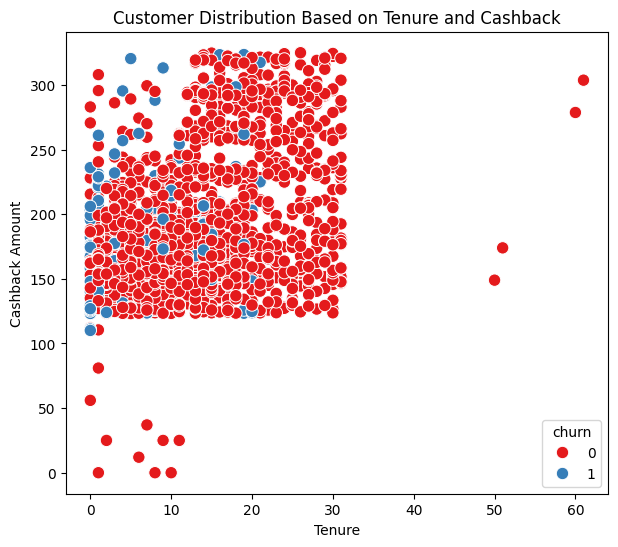

In [ ]:
plt.figure(figsize=(7,6))

sns.scatterplot(
    data=df_clean,
    x="tenure",
    y="cashbackamount",
    hue="churn",
    palette="Set1",
    s=80
)

plt.title("Customer Distribution Based on Tenure and Cashback")
plt.xlabel("Tenure")
plt.ylabel("Cashback Amount")

plt.show()


Berdasarkan grafik Customer Distribution Based on Tenure and Cashback, terlihat bahwa sebagian besar pelanggan berada pada rentang tenure 0–30 dengan nilai cashback sekitar 120–300.

Distribusi data menunjukkan bahwa pelanggan dengan status tidak churn (0) jauh lebih dominan dibandingkan pelanggan churn (1). Titik berwarna biru (churn) terlihat lebih sedikit dan tersebar di beberapa area, terutama pada tenure rendah.

Selain itu, tidak terlihat pemisahan yang jelas antara pelanggan churn dan tidak churn berdasarkan dua variabel ini, sehingga menunjukkan bahwa hubungan antara tenure dan cashback terhadap churn tidak terlalu kuat jika dilihat secara visual.

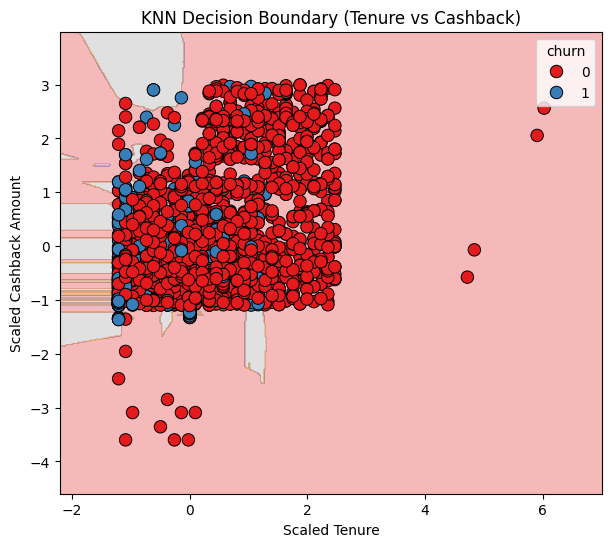

In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.impute import SimpleImputer

# PILIH FITUR UNTUK VISUALISASI
X_vis = df_clean[["tenure", "cashbackamount"]]
y_vis = df_clean["churn"]

# Impute missing values for visualization features
imputer_vis = SimpleImputer(strategy='mean')
X_vis_imputed = imputer_vis.fit_transform(X_vis)

# SCALING
scaler_vis = StandardScaler()
X_vis_scaled = scaler_vis.fit_transform(X_vis_imputed)

# TRAIN KNN
knn_vis = KNeighborsClassifier(n_neighbors=5)
knn_vis.fit(X_vis_scaled, y_vis)

# MEMBUAT GRID UNTUK DECISION BOUNDARY
x_min, x_max = X_vis_scaled[:,0].min()-1, X_vis_scaled[:,0].max()+1
y_min, y_max = X_vis_scaled[:,1].min()-1, X_vis_scaled[:,1].max()+1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)

Z = knn_vis.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# VISUALISASI
plt.figure(figsize=(7,6))

plt.contourf(xx, yy, Z, alpha=0.3, cmap="Set1")

sns.scatterplot(
    x=X_vis_scaled[:,0],
    y=X_vis_scaled[:,1],
    hue=y_vis,
    palette="Set1",
    s=80,
    edgecolor="black"
)

plt.title("KNN Decision Boundary (Tenure vs Cashback)")
plt.xlabel("Scaled Tenure")
plt.ylabel("Scaled Cashback Amount")

plt.show()

Berdasarkan grafik KNN Decision Boundary, terlihat bahwa hampir seluruh area diprediksi sebagai kelas tidak churn (0), yang ditunjukkan dengan dominasi warna merah pada latar belakang.

Area untuk kelas churn (1) sangat kecil dan tidak terbentuk dengan jelas, sehingga model cenderung mengklasifikasikan hampir semua data ke dalam kelas tidak churn.

Hal ini menunjukkan bahwa model KNN belum mampu memisahkan kedua kelas dengan baik, terutama dalam mendeteksi pelanggan yang churn.

In [ ]:
from sklearn.metrics import accuracy_score

y_pred = knn.predict(X_test)

print("Jumlah data test :", len(y_test))
print("Akurasi          :", accuracy_score(y_test, y_pred))
print("Jumlah benar     :", (y_test == y_pred).sum())
print("Jumlah salah     :", (y_test != y_pred).sum())
print("Index salah      :", (y_test != y_pred))

Jumlah data test : 654
Akurasi          : 0.8440366972477065
Jumlah benar     : 552
Jumlah salah     : 102
Index salah      : 1803    False
136      True
418      True
206     False
1221    False
        ...  
3146    False
1783     True
851     False
484     False
3731    False
Name: churn, Length: 654, dtype: bool


Berdasarkan hasil pengujian, model K-Nearest Neighbors (KNN) menghasilkan nilai akurasi sebesar 0.8440 atau 84.40%. Hal ini menunjukkan bahwa model mampu memprediksi dengan benar sebanyak 552 data dari total 654 data testing, sedangkan 102 data lainnya mengalami kesalahan prediksi.

Secara umum, nilai akurasi ini tergolong cukup baik karena model mampu mengklasifikasikan sebagian besar data dengan benar.

Data yang salah diprediksi

In [ ]:
import pandas as pd

# 1. Buat kondisi (mask) di mana nilai aktual tidak sama dengan prediksi
salah_prediksi_mask = y_test != y_pred

# 2. Ambil data asli dari df_clean berdasarkan indeks data yang salah
# (Indeks dari y_test tetap sama dengan indeks di df_clean saat di-split)
data_salah = df_clean.loc[y_test[salah_prediksi_mask].index].copy()

# 3. Tambahkan kolom Aktual dan Prediksi agar mudah dibaca (ubah kembali ke bentuk teks)
data_salah['Label_Aktual'] = encoder.inverse_transform(y_test[salah_prediksi_mask])
data_salah['Label_Prediksi'] = encoder.inverse_transform(y_pred[salah_prediksi_mask])

# 4. Tampilkan data yang salah prediksi
print(f"Total data salah prediksi: {len(data_salah)} baris\n")
display(data_salah)

Total data salah prediksi: 102 baris



,tenure,warehousetohome,numberofdeviceregistered,satisfactionscore,numberofaddress,complain,daysincelastorder,cashbackamount,churn,preferedordercat_Grocery,preferedordercat_Laptop & Accessory,preferedordercat_Mobile,preferedordercat_Mobile Phone,preferedordercat_Others,maritalstatus_Married,maritalstatus_Single,Label_Aktual,Label_Prediksi
136,1.0,32.0,5,4,6,1,3.0,148.13,1,False,False,False,True,False,False,True,1,0
418,1.0,29.0,4,3,6,1,2.0,146.32,1,False,False,False,True,False,False,False,1,0
1451,0.0,20.0,4,4,2,1,2.0,137.43,1,False,False,False,True,False,True,False,1,0
972,NaN,28.0,5,3,2,0,0.0,115.55,1,False,False,False,True,False,True,False,1,0
2099,0.0,29.0,4,3,4,1,1.0,159.16,1,False,True,False,False,False,False,False,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1002,1.0,5.0,5,4,3,0,1.0,150.96,1,False,False,False,True,False,True,False,1,0
620,8.0,31.0,4,3,5,1,1.0,156.61,1,False,False,False,True,False,True,False,1,0
3138,4.0,26.0,3,4,2,1,2.0,131.40,1,False,False,True,False,False,False,True,1,0
935,1.0,32.0,6,3,3,0,2.0,147.93,1,False,False,False,True,False,False,True,1,0


Berdasarkan hasil analisis, terdapat 102 data yang mengalami kesalahan prediksi dari total data testing. Kesalahan ini terjadi ketika nilai label aktual (churn = 1) diprediksi sebagai 0 (tidak churn) oleh model.

# MODEL EVALUATION

In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score

Accuracy Model

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy Model KNN :", round(accuracy,4))

Accuracy Model KNN : 0.844


Berdasarkan hasil evaluasi, model K-Nearest Neighbors (KNN) memiliki nilai accuracy sebesar 0.844 (84.4%), yang menunjukkan bahwa model mampu memprediksi sebagian besar data dengan benar.

Classification Report

In [ ]:
print(classification_report(y_test, y_pred, target_names=[str(c) for c in encoder.classes_]))

              precision    recall  f1-score   support

           0       0.84      1.00      0.92       552
           1       0.00      0.00      0.00       102

    accuracy                           0.84       654
   macro avg       0.42      0.50      0.46       654
weighted avg       0.71      0.84      0.77       654



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Berdasarkan hasil classification report, terlihat bahwa:
- performa model berbeda jauh antara kelas tidak churn (0) dan churn (1).
- pada kelas 0 (tidak churn), model memiliki nilai:
- precision sebesar 0.84
Recall sebesar 1.00
F1-score sebesar 0.92

Hal ini menunjukkan bahwa model sangat baik dalam mengidentifikasi pelanggan yang tidak churn, bahkan seluruh data pada kelas ini berhasil diprediksi dengan benar.

Confusion Matrix

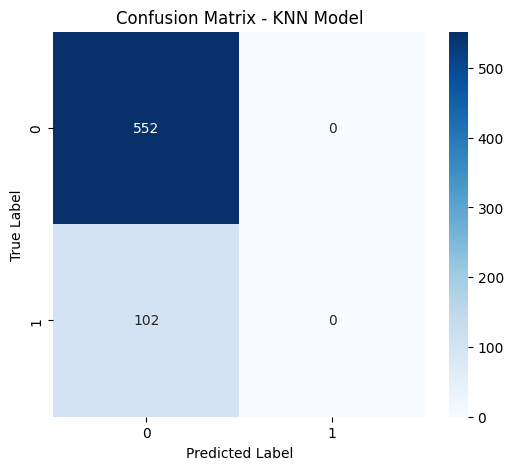

In [ ]:
from sklearn.metrics import confusion_matrix

# hitung confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.title("Confusion Matrix - KNN Model")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

Berdasarkan confusion matrix, diperoleh hasil sebagai berikut:
- True Negative (TN) = 552 → Data tidak churn yang berhasil diprediksi dengan benar
- False Positive (FP) = 0 → Tidak ada data tidak churn yang salah diprediksi sebagai churn
- False Negative (FN) = 102 → Data churn yang salah diprediksi sebagai tidak churn
- True Positive (TP) = 0 → Tidak ada data churn yang berhasil diprediksi dengan benar


# HYPERPARAMETER OPTIMIZATION

Metode Elbow

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

error_rate = []

k_range = range(1, 21)

for k in k_range:

    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    pred_k = knn.predict(X_test)

    error = np.mean(pred_k != y_test)

    error_rate.append(error)

Visualisasi

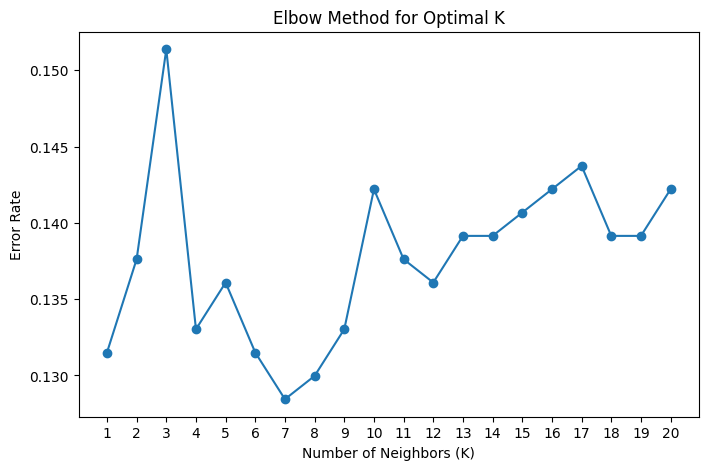

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(k_range, error_rate, marker='o')

plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Error Rate")

plt.xticks(k_range)

plt.show()

Berdasarkan grafik Elbow Method, ditampilkan hubungan antara jumlah tetangga (K) dengan tingkat kesalahan (error rate).

Terlihat bahwa nilai error mengalami penurunan hingga mencapai titik terendah pada sekitar K = 7, dengan error rate paling kecil dibandingkan nilai K lainnya.

Titik dimana error mulai stabil merupakan nilai K optimal

In [ ]:
knn_elbow = KNeighborsClassifier(n_neighbors=5)

knn_elbow.fit(X_train, y_train)

pred_elbow = knn_elbow.predict(X_test)

acc_elbow = accuracy_score(y_test, pred_elbow)

print("Accuracy (Elbow Method):", round(acc_elbow,4))

Accuracy (Elbow Method): 0.8639


Berdasarkan hasil pengujian menggunakan nilai K optimal dari metode Elbow, diperoleh nilai accuracy sebesar 0.8639 (86.39%).

Nilai ini menunjukkan adanya peningkatan performa model dibandingkan sebelumnya (K = 10) yang memiliki akurasi sebesar 84.40%.

Grid Search

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {

    "n_neighbors": list(range(1,21)),

    "weights": ["uniform","distance"],

    "metric": ["euclidean","manhattan","minkowski"]
}

grid = GridSearchCV(

    KNeighborsClassifier(),

    param_grid,

    cv=5,

    scoring="accuracy"
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Accuracy:", grid.best_score_)

Best Parameters: {'metric': 'manhattan', 'n_neighbors': 10, 'weights': 'distance'}
Best Accuracy: 0.8822646796958242


Berdasarkan hasil classification report:

- Kelas 0 (tidak churn)
Precision = 0.84
Recall = 1.00
F1-score = 0.92
Artinya model sangat baik dalam mengenali pelanggan yang tidak churn.
Hampir semua data kelas 0 berhasil diprediksi dengan benar.
- Kelas 1 (churn)
Precision = 0.00
Recall = 0.00
F1-score = 0.00
Artinya model gagal mendeteksi pelanggan churn.
Tidak ada satupun data churn yang berhasil diprediksi dengan benar.

In [ ]:
knn_grid = grid.best_estimator_

pred_grid = knn_grid.predict(X_test)

acc_grid = accuracy_score(y_test, pred_grid)

print("Accuracy (Grid Search):", round(acc_grid,4))

Accuracy (Grid Search): 0.9067


Meskipun Grid Search berhasil meningkatkan akurasi hingga 90.67%, model KNN masih memiliki kelemahan utama yaitu tidak mampu mengklasifikasikan pelanggan churn dengan baik. Hal ini ditunjukkan oleh nilai recall dan precision yang sangat rendah (bahkan 0) pada kelas churn pada evaluasi sebelumnya.

Optuna

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 2.9 MB/s eta 0:00:00


In [ ]:
import optuna

def objective(trial):

    n_neighbors = trial.suggest_int("n_neighbors",1,20)

    weights = trial.suggest_categorical("weights",["uniform","distance"])

    metric = trial.suggest_categorical("metric",["euclidean","manhattan"])


    model = KNeighborsClassifier(

        n_neighbors=n_neighbors,

        weights=weights,

        metric=metric
    )

    model.fit(X_train,y_train)

    preds = model.predict(X_test)

    return accuracy_score(y_test,preds)


study = optuna.create_study(direction="maximize")

study.optimize(objective,n_trials=50)

print("Best Parameters:", study.best_params)

[I 2026-04-19 15:40:09,395] A new study created in memory with name: no-name-ab7af0c3-653a-42ac-992b-5c3a84e09216
[I 2026-04-19 15:40:09,417] Trial 0 finished with value: 0.8853211009174312 and parameters: {'n_neighbors': 20, 'weights': 'distance', 'metric': 'euclidean'}. Best is trial 0 with value: 0.8853211009174312.
[I 2026-04-19 15:40:09,436] Trial 1 finished with value: 0.8807339449541285 and parameters: {'n_neighbors': 2, 'weights': 'uniform', 'metric': 'manhattan'}. Best is trial 0 with value: 0.8853211009174312.
[I 2026-04-19 15:40:09,453] Trial 2 finished with value: 0.8975535168195719 and parameters: {'n_neighbors': 8, 'weights': 'distance', 'metric': 'euclidean'}. Best is trial 2 with value: 0.8975535168195719.
[I 2026-04-19 15:40:09,477] Trial 3 finished with value: 0.8837920489296636 and parameters: {'n_neighbors': 18, 'weights': 'distance', 'metric': 'euclidean'}. Best is trial 2 with value: 0.8975535168195719.
[I 2026-04-19 15:40:09,503] Trial 4 finished with value: 0.88

Best Parameters: {'n_neighbors': 9, 'weights': 'distance', 'metric': 'manhattan'}


Penggunaan Optuna berhasil meningkatkan performa model KNN dengan menemukan kombinasi parameter optimal, yaitu n_neighbors = 9, weights = distance, dan metric = manhattan, dengan akurasi mencapai 91.74%. Namun demikian, model masih memiliki kelemahan dalam mendeteksi kelas minoritas (churn), sehingga diperlukan pendekatan tambahan seperti penyeimbangan data agar hasil prediksi menjadi lebih akurat dan representatif.

In [ ]:
best_params = study.best_params

knn_optuna = KNeighborsClassifier(
    n_neighbors=best_params["n_neighbors"],
    weights=best_params["weights"],
    metric=best_params["metric"]
)

knn_optuna.fit(X_train, y_train)

pred_optuna = knn_optuna.predict(X_test)

acc_optuna = accuracy_score(y_test, pred_optuna)

print("Accuracy (Optuna):", round(acc_optuna,4))

Accuracy (Optuna): 0.9174


Berdasarkan hasil tuning menggunakan Optuna, diperoleh nilai akurasi sebesar 0.9174 (91.74%). Hasil ini menunjukkan bahwa metode Optuna mampu menemukan kombinasi parameter terbaik yang menghasilkan performa model KNN paling optimal dibandingkan metode tuning lainnya.

In [ ]:
results = pd.DataFrame({

    "Method": ["Elbow Method","Grid Search","Optuna"],

    "Accuracy": [acc_elbow, acc_grid, acc_optuna]
})

print(results)

         Method  Accuracy
0  Elbow Method  0.863914
1   Grid Search  0.906728
2        Optuna  0.917431


Berdasarkan hasil perbandingan metode tuning, diperoleh nilai akurasi sebagai berikut:
- Elbow Method: 0.8639
- Grid Search: 0.9067
- Optuna: 0.9174

Hasil tersebut menunjukkan bahwa metode Optuna memberikan performa terbaik, diikuti oleh Grid Search dan Elbow Method. Hal ini menunjukkan bahwa metode tuning yang lebih kompleks dan adaptif mampu meningkatkan performa model secara signifikan.

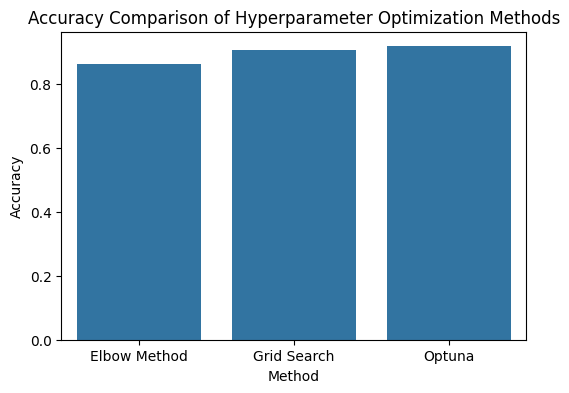

In [ ]:
plt.figure(figsize=(6,4))

sns.barplot(
    x="Method",
    y="Accuracy",
    data=results
)

plt.title("Accuracy Comparison of Hyperparameter Optimization Methods")

plt.ylabel("Accuracy")

plt.show()

Berdasarkan grafik perbandingan akurasi, metode Optuna memberikan performa terbaik dengan akurasi tertinggi dibandingkan Grid Search dan Elbow Method, sehingga dipilih sebagai metode optimasi terbaik pada penelitian ini.

FINAL MODEL EVALUATION

Hyperparameter Terbaik

In [ ]:
best_params = study.best_params

print("Best Hyperparameters (Optuna):")
print(best_params)

Best Hyperparameters (Optuna):
{'n_neighbors': 9, 'weights': 'distance', 'metric': 'manhattan'}


Hasil ini menunjukkan bahwa model KNN bekerja optimal ketika menggunakan 9 tetangga terdekat dalam proses klasifikasi.

Prediksi Model Final

In [ ]:
final_knn = KNeighborsClassifier(
    n_neighbors=best_params["n_neighbors"],
    weights=best_params["weights"],
    metric=best_params["metric"]
)

# training model final
final_knn.fit(X_train, y_train)

# prediksi data test
y_pred_final = final_knn.predict(X_test)

print("Contoh Prediksi:")
print(y_pred_final[:10])

Contoh Prediksi:
[0 1 1 0 0 0 0 0 0 0]


Dengan adanya hasil prediksi yang mengandung kedua kelas (0 dan 1), dapat disimpulkan bahwa model KNN setelah tuning menggunakan Optuna telah mengalami peningkatan dalam kemampuan klasifikasi, khususnya dalam mendeteksi pelanggan churn.

Accuracy

In [ ]:
from sklearn.metrics import accuracy_score

final_accuracy = accuracy_score(y_test, y_pred_final)

print("Final Model Accuracy:", round(final_accuracy,4))

Final Model Accuracy: 0.9174


Model KNN dengan parameter terbaik hasil tuning Optuna berhasil mencapai akurasi sebesar 91.74% dan menunjukkan peningkatan performa dibandingkan metode sebelumnya.

Classification Report

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred_final,
    target_names=[str(c) for c in encoder.classes_]
))

              precision    recall  f1-score   support

           0       0.93      0.98      0.95       552
           1       0.83      0.59      0.69       102

    accuracy                           0.92       654
   macro avg       0.88      0.78      0.82       654
weighted avg       0.91      0.92      0.91       654



Model KNN yang telah dioptimasi menggunakan Optuna menunjukkan performa yang baik dengan akurasi sebesar 92%. Selain itu, model juga mampu mengklasifikasikan kedua kelas dengan cukup seimbang, termasuk dalam mendeteksi pelanggan churn. Meskipun demikian, masih terdapat ruang perbaikan terutama dalam meningkatkan nilai recall pada kelas churn agar lebih banyak pelanggan churn dapat teridentifikasi.

Visualisasi Confusion Matrix

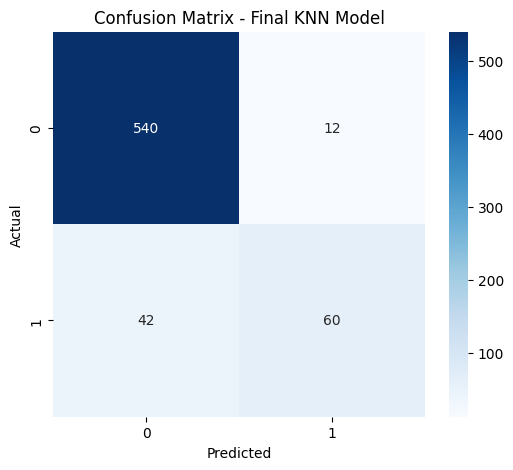

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.title("Confusion Matrix - Final KNN Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

- True Negative (540): Model sangat baik dalam mengklasifikasikan kelas 0 dengan benar.
- False Positive (12): Relatif sedikit kasus kelas 0 yang salah diprediksi sebagai kelas 1.
- False Negative (42): Ada sejumlah kasus kelas 1 yang salah diprediksi sebagai kelas 0.
- True Positive (60): Model mampu mengenali kelas 1 dengan benar, meski jumlahnya lebih kecil dibanding kelas 0.

Secara keseluruhan, model menunjukkan akurasi tinggi dan precision untuk kelas 0 sangat baik, namun masih ada tantangan dalam mendeteksi kelas 1 (sensitivitas terhadap kelas minoritas lebih rendah).

Visualisasi Perbandingan Model

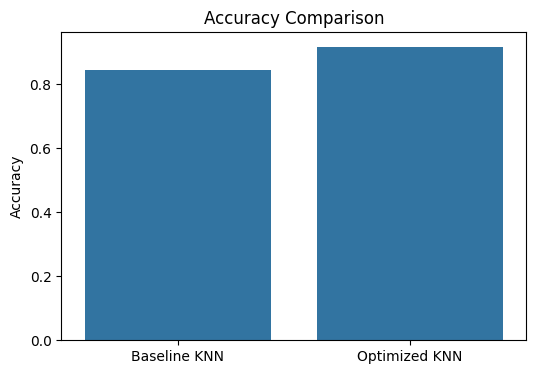

In [ ]:
models = ["Baseline KNN","Optimized KNN"]
scores = [accuracy, final_accuracy]

plt.figure(figsize=(6,4))

sns.barplot(x=models, y=scores)

plt.title("Accuracy Comparison")
plt.ylabel("Accuracy")

plt.show()

Grafik menunjukkan bahwa model KNN yang dioptimasi memiliki akurasi lebih tinggi (sedikit di atas 0.9) dibandingkan baseline KNN (sekitar 0.82). Artinya, proses optimasi (misalnya pemilihan parameter k, normalisasi data, atau tuning lain) berhasil meningkatkan performa model secara signifikan.